# Iterative Continuous-Solubility CVAE + DEEPCHEM/XGBoost

This notebook implements the iterative workflow:

1. Train the DEEPCHEM/XGBoost solubility predictor once.
2. Load the original ECFP + experimental solubility dataset.
3. Train a continuous conditional VAE.
4. Generate ECFP fingerprints conditioned on a target solubility.
5. Predict generated solubilities with the fixed XGBoost model.
6. Append generated fingerprints and predicted solubilities.
7. Retrain the VAE on the augmented dataset.
8. Repeat and save statistics/plots.

**Important:** the target solubility is the VAE generation condition; the solubility appended to the augmented dataset is the value predicted by the fixed DEEPCHEM/XGBoost model.

### Notebook output
- Every iteration histogram is displayed inline and saved as PNG.
- The combined all-iterations histogram is displayed inline and saved.
- Threshold matrices show p20, p50, p80 and p90.
- The training-dataset threshold matrix is saved as `threshold_matrix_training_datasets.csv`.

In [36]:
"""
Iterative Continuous-Solubility CVAE + DEEPCHEM/XGBoost Loop

Workflow
--------
1. Train the DEEPCHEM/XGBoost ESOL predictor once.
2. Load the original ECFP + experimental solubility dataset.
3. Train the continuous conditional VAE on the current dataset.
4. Generate ECFP fingerprints conditioned on a high target solubility.
5. Predict the generated fingerprints' solubility with the fixed XGBoost model.
6. Append generated fingerprints + predicted solubility to the training dataset.
7. Retrain the VAE on the augmented dataset.
8. Repeat.
9. Save histograms, statistics, generated samples, and augmented datasets.

Important
---------
The target solubility is used only as the CONDITION for generation.
The label appended to the augmented dataset is the solubility PREDICTED
by the fixed DEEPCHEM/XGBoost model.

The XGBoost predictor is kept fixed across iterations to avoid changing
the evaluation function during the iterative experiment.

Expected files
--------------
- esol_dataset.csv
- This script

Required packages
-----------------
numpy
pandas
matplotlib
tensorflow
deepchem
xgboost
scikit-learn
"""

from __future__ import annotations

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

import deepchem as dc
import xgboost as xgb

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# ============================================================
# CONFIGURATION

In [60]:
# ============================================================

# ------------------------------------------------------------
# Input / output
# ------------------------------------------------------------

ESOL_CSV = "esol_dataset.csv"

OUTPUT_DIR = Path("iterative_cvae_results")

# ------------------------------------------------------------
# Iterative experiment
# ------------------------------------------------------------

N_ITERATIONS = 5

N_GENERATED_PER_ITERATION = 1000

# High solubility used as the VAE generation condition.
TARGET_SOLUBILITY = 2.5

# Decoder sampling temperature.
TEMPERATURE = 1.0

# ------------------------------------------------------------
# VAE
# ------------------------------------------------------------

LATENT_DIM = 128

LABEL_DIM = 1

LABEL_EMBED_DIM = 16

VAE_EPOCHS = 100

BATCH_SIZE = 100

LEARNING_RATE = 5e-4

BETA = 0.1

MAX_BETA = 1.0

BETA_WARMUP_EPOCHS = 80

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 123

# ------------------------------------------------------------
# Optional duplicate removal
# ------------------------------------------------------------
# False = append every generated sample.
# True  = remove duplicate generated ECFP rows before augmentation.
#
# I recommend starting with False so that the experiment follows
# the requested augmentation procedure exactly.

DEDUPLICATE_GENERATED = False

In [ ]:
# ============================================================
# REPRODUCIBILITY

In [38]:
# ============================================================

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
# ============================================================
# UTILITY

In [39]:
# ============================================================

def print_section(title: str) -> None:
    print()
    print("=" * 70)
    print(title)
    print("=" * 70)

In [ ]:
# ============================================================
# 1. TRAIN DEEPCHEM / XGBOOST SOLUBILITY PREDICTOR

In [40]:
# ============================================================

def train_deepchem_predictor():
    """
    Train the fixed XGBoost ESOL predictor using the same
    DeepChem Delaney/ESOL setup as the supplied DEEPCHEM notebook.
    """

    print_section(
        "1. TRAIN DEEPCHEM / XGBOOST SOLUBILITY PREDICTOR"
    )

    tasks, datasets, transformers = dc.molnet.load_delaney(
        featurizer="ECFP",
        split="random"
    )

    train_dataset, valid_dataset, test_dataset = datasets

    X_train = train_dataset.X
    y_train = train_dataset.y.ravel()

    X_valid = valid_dataset.X
    y_valid = valid_dataset.y.ravel()

    X_test = test_dataset.X
    y_test = test_dataset.y.ravel()

    print("DeepChem train shape:", X_train.shape)
    print("DeepChem valid shape:", X_valid.shape)
    print("DeepChem test shape :", X_test.shape)

    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_SEED
    )

    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[
            (X_valid, y_valid)
        ],
        verbose=False
    )

    y_pred_test = xgb_model.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred_test
        )
    )

    r2 = r2_score(
        y_test,
        y_pred_test
    )

    print()
    print("Fixed DEEPCHEM/XGBoost predictor")
    print("--------------------------------")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R²  : {r2:.6f}")

    return xgb_model

In [ ]:
# ============================================================
# 2. LOAD ORIGINAL ESOL DATASET

In [41]:
# ============================================================

def load_original_esol():
    """
    Load the supplied ESOL CSV.

    According to the supplied VAE notebook:
        real_data.iloc[:, :-2] = ECFP features
        real_data.iloc[:, -2]   = solubility
    """

    print_section(
        "2. LOAD ORIGINAL ESOL DATASET"
    )

    real_data = pd.read_csv(
        ESOL_CSV
    )

    # ECFP fingerprint columns
    real_samples = real_data.iloc[
        :, :-2
    ]

    # Experimental continuous solubility
    real_solubility = real_data.iloc[
        :, -2
    ].values.astype(
        np.float32
    )

    X_original = real_samples.values.astype(
        np.float32
    )

    print(
        "Original dataset shape:",
        real_data.shape
    )

    print(
        "Original ECFP shape:",
        X_original.shape
    )

    print(
        "Original solubility shape:",
        real_solubility.shape
    )

    print(
        "Original solubility range:",
        float(real_solubility.min()),
        "to",
        float(real_solubility.max())
    )

    return (
        real_data,
        X_original,
        real_solubility,
        real_samples.columns.tolist()
    )

In [ ]:
# ============================================================
# 3. CONDITIONAL VAE ENCODER

In [42]:
# ============================================================

def build_conditional_encoder(
    input_dim: int,
    label_dim: int,
    latent_dim: int,
    hidden_layers=(512, 256, 128),
    activation="elu",
    use_label_embedding=True,
    label_embed_dim=16,
):
    """
    Continuous-condition encoder.

    y -> Dense(label_embed_dim) -> condition representation

    The same Dense weights are used for every solubility value.
    """

    x_in = tf.keras.Input(
        shape=(input_dim,),
        name="x"
    )

    y_in = tf.keras.Input(
        shape=(label_dim,),
        name="y"
    )

    y_feat = y_in

    if use_label_embedding:
        y_feat = tf.keras.layers.Dense(
            label_embed_dim,
            activation=activation,
            name="y_embed"
        )(y_in)

    h = tf.keras.layers.Concatenate(
        name="enc_concat"
    )(
        [x_in, y_feat]
    )

    for i, units in enumerate(
        hidden_layers
    ):
        h = tf.keras.layers.Dense(
            units,
            activation=activation,
            name=f"enc_dense_{i}"
        )(h)

    z_mean = tf.keras.layers.Dense(
        latent_dim,
        name="z_mean"
    )(h)

    z_logvar = tf.keras.layers.Dense(
        latent_dim,
        name="z_logvar"
    )(h)

    return tf.keras.Model(
        [x_in, y_in],
        [z_mean, z_logvar],
        name="cvae_encoder"
    )

In [ ]:
# ============================================================
# 4. CONDITIONAL VAE DECODER

In [43]:
# ============================================================

def build_conditional_decoder(
    input_dim: int,
    label_dim: int,
    latent_dim: int,
    hidden_layers=(128, 256, 512),
    activation="gelu",
    use_label_embedding=True,
    label_embed_dim= 16,
):
    """
    Continuous-condition decoder.

    z + f_theta(y) -> generated ECFP logits
    """

    z_in = tf.keras.Input(
        shape=(latent_dim,),
        name="z"
    )

    y_in = tf.keras.Input(
        shape=(label_dim,),
        name="y"
    )

    y_feat = y_in

    if use_label_embedding:
        y_feat = tf.keras.layers.Dense(
            label_embed_dim,
            activation=activation,
            name="y_embed"
        )(y_in)

    h = tf.keras.layers.Concatenate(
        name="dec_concat"
    )(
        [z_in, y_feat]
    )

    for i, units in enumerate(
        hidden_layers
    ):
        h = tf.keras.layers.Dense(
            units,
            activation=activation,
            name=f"dec_dense_{i}"
        )(h)

    # Output logits.
    # Sigmoid is applied only for reconstruction/sampling.
    x_logits = tf.keras.layers.Dense(
        input_dim,
        activation=None,
        name="x_logits"
    )(h)

    return tf.keras.Model(
        [z_in, y_in],
        x_logits,
        name="cvae_decoder"
    )

In [ ]:
# ============================================================
# 5. VAE REPARAMETERIZATION

In [44]:
# ============================================================

def sampling(
    z_mean,
    z_logvar
):
    """
    Reparameterization trick:
        z = mu + sigma * epsilon
    """

    eps = tf.random.normal(
        tf.shape(z_mean)
    )

    return (
        z_mean
        +
        tf.exp(
            0.5 * z_logvar
        )
        *
        eps
    )

In [ ]:
# ============================================================
# 6. CONDITIONAL VAE MODEL

In [45]:
# ============================================================

class ConditionalVAE(
    tf.keras.Model
):

    def __init__(
        self,
        encoder,
        decoder,
        beta=0.1,
        max_beta=1.0,
        warmup_epochs=80,
        name="ConditionalVAE"
    ):
        super().__init__(
            name=name
        )

        self.encoder = encoder
        self.decoder = decoder

        self.beta = float(beta)
        self.max_beta = float(max_beta)
        self.warmup_epochs = int(
            warmup_epochs
        )

        self.loss_tracker = (
            tf.keras.metrics.Mean(
                name="loss"
            )
        )

        self.recon_tracker = (
            tf.keras.metrics.Mean(
                name="recon"
            )
        )

        self.kl_tracker = (
            tf.keras.metrics.Mean(
                name="kl"
            )
        )

        self.beta_tracker = (
            tf.keras.metrics.Mean(
                name="beta"
            )
        )

        self._epoch_var = tf.Variable(
            0,
            dtype=tf.int32,
            trainable=False
        )

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.recon_tracker,
            self.kl_tracker,
            self.beta_tracker
        ]

    def set_epoch(
        self,
        epoch: int
    ):
        self._epoch_var.assign(
            int(epoch)
        )

    def _current_beta(self):
        if self.warmup_epochs <= 0:
            return tf.constant(
                self.max_beta,
                dtype=tf.float32
            )

        e = tf.cast(
            self._epoch_var,
            tf.float32
        )

        w = tf.cast(
            self.warmup_epochs,
            tf.float32
        )

        frac = tf.clip_by_value(
            e / w,
            0.0,
            1.0
        )

        return (
            tf.constant(
                self.beta,
                tf.float32
            )
            +
            frac
            *
            (
                tf.constant(
                    self.max_beta,
                    tf.float32
                )
                -
                tf.constant(
                    self.beta,
                    tf.float32
                )
            )
        )

    def _reconstruction_loss(
        self,
        x,
        logits
    ):
        per_dim = (
            tf.nn
            .sigmoid_cross_entropy_with_logits(
                labels=x,
                logits=logits
            )
        )

        return tf.reduce_mean(
            tf.reduce_sum(
                per_dim,
                axis=1
            )
        )

    def train_step(
        self,
        data
    ):
        (x, y), _ = data

        with tf.GradientTape() as tape:

            z_mean, z_logvar = (
                self.encoder(
                    [x, y],
                    training=True
                )
            )

            z = sampling(
                z_mean,
                z_logvar
            )

            logits = self.decoder(
                [z, y],
                training=True
            )

            recon = (
                self._reconstruction_loss(
                    x,
                    logits
                )
            )

            kl = tf.reduce_mean(
                -0.5
                *
                tf.reduce_sum(
                    1
                    + z_logvar
                    - tf.square(
                        z_mean
                    )
                    - tf.exp(
                        z_logvar
                    ),
                    axis=1
                )
            )

            beta = (
                self._current_beta()
            )

            loss = (
                recon
                +
                beta * kl
            )

        grads = tape.gradient(
            loss,
            self.trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(
                grads,
                self.trainable_variables
            )
        )

        self.loss_tracker.update_state(
            loss
        )

        self.recon_tracker.update_state(
            recon
        )

        self.kl_tracker.update_state(
            kl
        )

        self.beta_tracker.update_state(
            beta
        )

        return {
            m.name: m.result()
            for m in self.metrics
        }

    def call(
        self,
        inputs,
        training=False
    ):
        x, y = inputs

        z_mean, z_logvar = (
            self.encoder(
                [x, y],
                training=training
            )
        )

        z = sampling(
            z_mean,
            z_logvar
        )

        return self.decoder(
            [z, y],
            training=training
        )


class EpochSetter(
    tf.keras.callbacks.Callback
):

    def on_epoch_begin(
        self,
        epoch,
        logs=None
    ):
        self.model.set_epoch(
            epoch
        )

In [ ]:
# ============================================================
# 7. TRAIN A NEW VAE

In [46]:
# ============================================================

def train_vae(
    X_data,
    y_data,
    input_dim
):
    """
    Train a fresh CVAE on the current augmented dataset.

    y_data is the continuous predicted/experimental solubility.
    """

    encoder = build_conditional_encoder(
        input_dim=input_dim,
        label_dim=LABEL_DIM,
        latent_dim=LATENT_DIM,
        hidden_layers=(
            512,
            256,
            128
        ),
        activation="elu",
        use_label_embedding=True,
        label_embed_dim=LABEL_EMBED_DIM
    )

    decoder = build_conditional_decoder(
        input_dim=input_dim,
        label_dim=LABEL_DIM,
        latent_dim=LATENT_DIM,
        hidden_layers=(
            28,
            256,
            512
        ),
        activation="gelu",
        use_label_embedding=True,
        label_embed_dim=LABEL_EMBED_DIM
    )

    model = ConditionalVAE(
        encoder=encoder,
        decoder=decoder,
        beta=BETA,
        max_beta=MAX_BETA,
        warmup_epochs=BETA_WARMUP_EPOCHS
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        )
    )

    y_data = np.asarray(
        y_data,
        dtype=np.float32
    ).reshape(
        -1,
        1
    )

    history = model.fit(
        x=(
            X_data,
            y_data
        ),
        y=X_data,
        epochs=VAE_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[
            EpochSetter()
        ],
        verbose=1
    )

    return model, history

In [ ]:
# ============================================================
# 8. GENERATE CONDITIONAL SAMPLES

In [47]:
# ============================================================

def generate_conditioned(
    decoder,
    target_solubility,
    n,
    temperature=1.0
):
    """
    Generate ECFP fingerprints conditioned on one continuous
    target solubility.

    The target is the requested conditioning value only.
    It is NOT used as the label of the generated samples.

    DEEPCHEM/XGBoost later predicts the label that is appended
    to the augmented dataset.
    """

    if temperature <= 0:
        raise ValueError(
            "temperature must be > 0"
        )

    y_cond = np.full(
        (n, 1),
        float(target_solubility),
        dtype=np.float32
    )

    y_cond = tf.convert_to_tensor(
        y_cond,
        dtype=tf.float32
    )

    # Sample z ~ N(0, I)
    z = tf.random.normal(
        (
            n,
            LATENT_DIM
        )
    )

    # Decoder outputs logits
    logits = decoder(
        [z, y_cond],
        training=False
    )

    # Temperature-scaled Bernoulli probabilities
    probs = tf.sigmoid(
        logits / temperature
    )

    # Sample each ECFP bit
    random_values = tf.random.uniform(
        tf.shape(probs)
    )

    x_generated = tf.cast(
        random_values < probs,
        tf.float32
    )

    return x_generated.numpy()

In [ ]:
# ============================================================
# 9. PREDICT GENERATED SOLUBILITIES

In [48]:
# ============================================================

def predict_generated_solubility(
    X_generated,
    predictor
):
    """
    Predict continuous ESOL values for generated ECFPs.
    """

    predictions = predictor.predict(
        X_generated
    )

    predictions = np.asarray(
        predictions
    ).ravel()

    return predictions

In [ ]:
# ============================================================
# 10. CLEAN GENERATED DATA

In [49]:
# ============================================================

def clean_generated_data(
    X_generated,
    y_generated
):
    """
    Remove rows with NaN or infinite predictions.
    """

    mask = np.isfinite(
        y_generated
    )

    X_clean = X_generated[
        mask
    ]

    y_clean = y_generated[
        mask
    ]

    return X_clean, y_clean

In [ ]:
# ============================================================
# 11. OPTIONAL DUPLICATE REMOVAL

In [50]:
# ============================================================

def remove_duplicate_fingerprints(
    X_generated,
    y_generated
):
    """
    Remove exact duplicate ECFP fingerprints.

    The first occurrence is retained.
    """

    X_df = pd.DataFrame(
        X_generated
    )

    duplicate_mask = (
        X_df
        .duplicated(
            keep="first"
        )
        .values
    )

    keep = ~duplicate_mask

    return (
        X_generated[keep],
        y_generated[keep]
    )

In [ ]:
# ============================================================
# 12. CALCULATE STATISTICS

In [51]:
# ============================================================

def calculate_statistics(
    y_generated,
    y_original
):
    """
    Calculate the same type of KPI statistics used in the
    supplied DEEPCHEM notebook.
    """

    y_generated = np.asarray(
        y_generated
    ).ravel()

    y_original = np.asarray(
        y_original
    ).ravel()

    threshold_80 = np.percentile(
        y_original,
        80
    )

    threshold_90 = np.percentile(
        y_original,
        90
    )

    n = len(
        y_generated
    )

    n_above_80 = np.sum(
        y_generated
        >=
        threshold_80
    )

    n_above_90 = np.sum(
        y_generated
        >=
        threshold_90
    )

    return {
        "N": n,

        "mean": float(
            np.mean(y_generated)
        ),

        "median": float(
            np.median(y_generated)
        ),

        "std": float(
            np.std(y_generated)
        ),

        "min": float(
            np.min(y_generated)
        ),

        "max": float(
            np.max(y_generated)
        ),

        "80th_percentile": float(
            np.percentile(
                y_generated,
                80
            )
        ),

        "90th_percentile": float(
            np.percentile(
                y_generated,
                90
            )
        ),

        "original_80th_threshold": float(
            threshold_80
        ),

        "original_90th_threshold": float(
            threshold_90
        ),

        "n_above_original_80": int(
            n_above_80
        ),

        "percent_above_original_80": float(
            100.0
            *
            n_above_80
            /
            n
        ) if n > 0 else 0.0,

        "n_above_original_90": int(
            n_above_90
        ),

        "percent_above_original_90": float(
            100.0
            *
            n_above_90
            /
            n
        ) if n > 0 else 0.0
    }

## 13. THRESHOLD MATRICES

The notebook prints percentile threshold matrices during the iterative experiment. It includes p20 (the threshold used in the original binary-label workflow), p50, p80 and p90 for the original/current training data, and for each generated predicted-solubility distribution.

In [52]:
# ============================================================
# 13. PRINT THRESHOLD MATRICES
# ============================================================

THRESHOLD_PERCENTILES = [20, 50, 80, 90]


def calculate_threshold_row(
    y_values,
    iteration,
    dataset_name
):
    """
    Calculate percentile thresholds for one dataset/iteration.
    """

    y_values = np.asarray(y_values).ravel()

    row = {
        "iteration": iteration,
        "dataset": dataset_name,
        "N": len(y_values)
    }

    for percentile in THRESHOLD_PERCENTILES:
        row[f"p{percentile}"] = float(
            np.percentile(y_values, percentile)
        )

    return row


def print_threshold_matrix(
    threshold_rows,
    title="THRESHOLD MATRIX"
):
    """
    Print a readable threshold matrix.
    """

    threshold_df = pd.DataFrame(threshold_rows)

    print()
    print("=" * 100)
    print(title)
    print("=" * 100)

    print(
        threshold_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )

    print()
    print("Numeric threshold matrix:")
    print(
        threshold_df[
            ["iteration", "dataset", "p20", "p50", "p80", "p90"]
        ].to_numpy()
    )

    return threshold_df


# Original experimental dataset thresholds.
original_threshold_df = print_threshold_matrix(
    [
        calculate_threshold_row(
            y_original_reference,
            iteration=0,
            dataset_name="original_experimental"
        )
    ],
    title="ORIGINAL DATASET THRESHOLD MATRIX"
)


NameError: name 'y_original_reference' is not defined

In [ ]:
# ============================================================
# 13. SAVE HISTOGRAM

In [53]:
# ============================================================
# 14. DISPLAY AND SAVE HISTOGRAMS
# ============================================================

def save_iteration_histogram(
    y_original,
    y_generated,
    iteration,
    target_solubility
):
    """
    Save AND display the histogram for this iteration.
    """

    plt.figure(figsize=(10, 6))

    plt.hist(
        y_original,
        bins=30,
        density=True,
        alpha=0.45,
        label="Original experimental ESOL"
    )

    plt.hist(
        y_generated,
        bins=30,
        density=True,
        alpha=0.55,
        label=f"Generated - iteration {iteration}"
    )

    original_mean = np.mean(y_original)
    generated_mean = np.mean(y_generated)

    threshold_80 = np.percentile(y_original, 80)
    threshold_90 = np.percentile(y_original, 90)

    plt.axvline(
        original_mean,
        linestyle="-.",
        linewidth=2,
        label=f"Original mean = {original_mean:.2f}"
    )

    plt.axvline(
        generated_mean,
        linestyle="--",
        linewidth=2,
        label=f"Generated mean = {generated_mean:.2f}"
    )

    plt.axvline(
        threshold_80,
        linestyle=":",
        linewidth=2,
        label=f"Original 80th percentile = {threshold_80:.2f}"
    )

    plt.axvline(
        threshold_90,
        linestyle=":",
        linewidth=2,
        label=f"Original 90th percentile = {threshold_90:.2f}"
    )

    plt.axvline(
        target_solubility,
        linestyle="--",
        linewidth=2,
        label=f"Generation target = {target_solubility:.2f}"
    )

    plt.xlabel("Solubility")
    plt.ylabel("Density")
    plt.title(f"Solubility Distribution: Iteration {iteration}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    filename = OUTPUT_DIR / f"histogram_iteration_{iteration}.png"

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight"
    )

    # Show every histogram directly in Jupyter.
    plt.show()


In [ ]:
# ============================================================
# 14. SAVE AUGMENTED DATASET

In [54]:
# ============================================================

def save_augmented_dataset(
    X_data,
    y_data,
    feature_names,
    iteration
):
    """
    Save the current VAE training dataset.

    Columns:
        ECFP_0 ... ECFP_n
        solubility
    """

    augmented_df = pd.DataFrame(
        X_data,
        columns=feature_names
    )

    augmented_df[
        "solubility"
    ] = np.asarray(
        y_data
    ).ravel()

    filename = (
        OUTPUT_DIR
        /
        f"augmented_dataset_after_iteration_{iteration}.csv"
    )

    augmented_df.to_csv(
        filename,
        index=False
    )

In [ ]:
# ============================================================
# 15. SAVE GENERATED DATASET

In [55]:
# ============================================================

def save_generated_dataset(
    X_generated,
    y_generated,
    feature_names,
    iteration
):
    """
    Save generated ECFP fingerprints together with the
    DEEPCHEM/XGBoost predicted solubility.
    """

    generated_df = pd.DataFrame(
        X_generated,
        columns=feature_names
    )

    generated_df[
        "predicted_solubility"
    ] = np.asarray(
        y_generated
    ).ravel()

    filename = (
        OUTPUT_DIR
        /
        f"generated_iteration_{iteration}.csv"
    )

    generated_df.to_csv(
        filename,
        index=False
    )

In [ ]:
# ============================================================
# 16. PLOT EVOLUTION ACROSS ITERATIONS

In [56]:
# ============================================================

def plot_evolution(
    results_df,
    y_original
):
    """
    Plot the evolution of generated mean and 90th percentile.
    """

    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        results_df["iteration"],
        results_df["mean"],
        marker="o",
        label="Generated mean"
    )

    plt.axhline(
        np.mean(y_original),
        linestyle=":",
        linewidth=2,
        label="Original mean"
    )

    plt.axhline(
        TARGET_SOLUBILITY,
        linestyle="--",
        linewidth=2,
        label="Generation target"
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Predicted solubility"
    )

    plt.title(
        "Evolution of Generated Solubility Mean"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        /
        "evolution_mean.png",
        dpi=200
    )

    plt.close()

    # --------------------------------------------------------
    # 90th percentile
    # --------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        results_df["iteration"],
        results_df["90th_percentile"],
        marker="o",
        label="Generated 90th percentile"
    )

    original_90 = np.percentile(
        y_original,
        90
    )

    plt.axhline(
        original_90,
        linestyle="--",
        linewidth=2,
        label="Original 90th percentile"
    )

    plt.axhline(
        TARGET_SOLUBILITY,
        linestyle=":",
        linewidth=2,
        label="Generation target"
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Predicted solubility"
    )

    plt.title(
        "Evolution of Generated 90th Percentile"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        /
        "evolution_90th_percentile.png",
        dpi=200
    )

    plt.close()

In [ ]:
# ============================================================
# 17. PLOT ALL ITERATIONS

In [57]:
# ============================================================

def plot_all_iterations(
    all_generated_predictions,
    y_original
):
    """
    Plot all generated solubility distributions together.
    """

    plt.figure(
        figsize=(11, 7)
    )

    plt.hist(
        y_original,
        bins=30,
        density=True,
        alpha=0.30,
        label="Original ESOL"
    )

    for iteration, values in (
        all_generated_predictions.items()
    ):

        plt.hist(
            values,
            bins=30,
            density=True,
            alpha=0.30,
            label=f"Iteration {iteration}"
        )

    plt.axvline(
        TARGET_SOLUBILITY,
        linestyle="--",
        linewidth=2,
        label="Generation target"
    )

    plt.xlabel(
        "Predicted solubility"
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        "Evolution of Generated Solubility Distribution"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        /
        "all_iterations_histogram.png",
        dpi=200
    )

    plt.close()

In [ ]:
# ============================================================
# 18. MAIN ITERATIVE EXPERIMENT

In [67]:
# ============================================================

def main():

    print_section(
        "ITERATIVE CONTINUOUS-SOLUBILITY VAE EXPERIMENT"
    )

    print(
        f"Iterations: {N_ITERATIONS}"
    )

    print(
        f"Samples per iteration: "
        f"{N_GENERATED_PER_ITERATION}"
    )

    print(
        f"Generation target: "
        f"{TARGET_SOLUBILITY}"
    )

    print(
        f"Temperature: "
        f"{TEMPERATURE}"
    )

    # --------------------------------------------------------
    # Train predictor ONCE
    # --------------------------------------------------------

    xgb_model = train_deepchem_predictor()

    # --------------------------------------------------------
    # Load original data
    # --------------------------------------------------------

    (
        real_data,
        X_original,
        y_original,
        feature_names
    ) = load_original_esol()

    input_dim = X_original.shape[1]

    # --------------------------------------------------------
    # Current VAE training dataset
    # --------------------------------------------------------
    #
    # Initially:
    #
    # D_0 = original experimental ESOL
    #
    # After iteration:
    #
    # D_{k+1} =
    # D_k U generated/predicted samples
    #
    # --------------------------------------------------------

    X_current = X_original.copy()

    y_current = y_original.copy()

    # Keep the original dataset fixed as the evaluation reference.
    y_original_reference = y_original.copy()

    all_statistics = []

    # Threshold matrix for every iteration's training dataset.
    threshold_rows = []

    all_generated_predictions = {}

    # --------------------------------------------------------
    # Iterative loop
    # --------------------------------------------------------

    for iteration in range(
        N_ITERATIONS
    ):

        print_section(
            f"ITERATION {iteration}"
        )

        print(
            "Current training dataset size:",
            len(X_current)
        )

        print(
            "Current solubility range:",
            float(y_current.min()),
            "to",
            float(y_current.max())
        )

        # ----------------------------------------------------
        # Print thresholds for the current training dataset
        # ----------------------------------------------------

        threshold_rows.append(
            calculate_threshold_row(
                y_current,
                iteration=iteration,
                dataset_name="current_training_dataset"
            )
        )

        print_threshold_matrix(
            threshold_rows,
            title=f"THRESHOLD MATRIX THROUGH ITERATION {iteration}"
        )

        # ----------------------------------------------------
        # A. Train VAE
        # ----------------------------------------------------

        print_section(
            f"ITERATION {iteration}: TRAIN VAE"
        )

        model, history = train_vae(
            X_data=X_current,
            y_data=y_current,
            input_dim=input_dim
        )

        # ----------------------------------------------------
        # B. Generate samples
        # ----------------------------------------------------

        print_section(
            f"ITERATION {iteration}: GENERATE SAMPLES"
        )

        X_generated = generate_conditioned(
            decoder=model.decoder,
            target_solubility=TARGET_SOLUBILITY,
            n=N_GENERATED_PER_ITERATION,
            temperature=TEMPERATURE
        )

        print(
            "Generated shape:",
            X_generated.shape
        )

        print(
            "Generated unique values:",
            np.unique(X_generated)
        )

        # ----------------------------------------------------
        # C. Predict solubility using fixed predictor
        # ----------------------------------------------------

        print_section(
            f"ITERATION {iteration}: DEEPCHEM PREDICTION"
        )

        y_generated_pred = (
            predict_generated_solubility(
                X_generated,
                xgb_model
            )
        )

        # ----------------------------------------------------
        # D. Clean invalid predictions
        # ----------------------------------------------------

        (
            X_generated,
            y_generated_pred
        ) = clean_generated_data(
            X_generated,
            y_generated_pred
        )

        # ----------------------------------------------------
        # Optional duplicate removal
        # ----------------------------------------------------

        if DEDUPLICATE_GENERATED:

            before = len(
                X_generated
            )

            (
                X_generated,
                y_generated_pred
            ) = remove_duplicate_fingerprints(
                X_generated,
                y_generated_pred
            )

            after = len(
                X_generated
            )

            print(
                "Duplicates removed:",
                before - after
            )

        print(
            "Valid generated samples:",
            len(X_generated)
        )

        # ----------------------------------------------------
        # E. Calculate statistics
        # ----------------------------------------------------

        stats = calculate_statistics(
            y_generated=y_generated_pred,
            y_original=y_original_reference
        )

        stats["iteration"] = (
            iteration
        )

        stats["generation_target"] = (
            TARGET_SOLUBILITY
        )

        all_statistics.append(
            stats
        )

        # Print thresholds of the generated predicted-solubility distribution.
        generated_threshold_df = print_threshold_matrix(
            [
                calculate_threshold_row(
                    y_generated_pred,
                    iteration=iteration,
                    dataset_name="generated_predicted"
                )
            ],
            title=f"GENERATED PREDICTED SOLUBILITY THRESHOLDS - ITERATION {iteration}"
        )

        # ----------------------------------------------------
        # Print KPI results
        # ----------------------------------------------------

        print()
        print(
            "----------------------------------------------"
        )
        print(
            "GENERATED ESOL KPI EVALUATION"
        )
        print(
            "----------------------------------------------"
        )

        print(
            "Number of predictions:",
            stats["N"]
        )

        print(
            "Mean ESOL:",
            stats["mean"]
        )

        print(
            "Median ESOL:",
            stats["median"]
        )

        print(
            "Standard deviation:",
            stats["std"]
        )

        print(
            "Minimum ESOL:",
            stats["min"]
        )

        print(
            "Maximum ESOL:",
            stats["max"]
        )

        print(
            "Original 80th percentile:",
            stats[
                "original_80th_threshold"
            ]
        )

        print(
            "Original 90th percentile:",
            stats[
                "original_90th_threshold"
            ]
        )

        print(
            "Generated 80th percentile:",
            stats["80th_percentile"]
        )

        print(
            "Generated 90th percentile:",
            stats["90th_percentile"]
        )

        print(
            "Percentage >= original 80th:",
            f"{stats['percent_above_original_80']:.2f}%"
        )

        print(
            "Percentage >= original 90th:",
            f"{stats['percent_above_original_90']:.2f}%"
        )

        # ----------------------------------------------------
        # F. Save generated samples
        # ----------------------------------------------------

        save_generated_dataset(
            X_generated=X_generated,
            y_generated=y_generated_pred,
            feature_names=feature_names,
            iteration=iteration
        )

        # ----------------------------------------------------
        # G. Save histogram
        # ----------------------------------------------------

        save_iteration_histogram(
            y_original=y_original_reference,
            y_generated=y_generated_pred,
            iteration=iteration,
            target_solubility=TARGET_SOLUBILITY
        )

        # ----------------------------------------------------
        # H. AUGMENT DATASET
        # ----------------------------------------------------
        #
        # IMPORTANT:
        #
        # The generated molecules are NOT assigned
        # TARGET_SOLUBILITY here.
        #
        # They receive their DEEPCHEM/XGBoost predictions.
        #
        # Therefore:
        #
        # X_new = X_old + X_generated
        #
        # y_new = y_old + y_predicted_generated
        #
        # ----------------------------------------------------

        print_section(
            f"ITERATION {iteration}: AUGMENT DATASET"
        )

        X_current = np.vstack(
            [
                X_current,
                X_generated
            ]
        )

        y_current = np.concatenate(
            [
                y_current,
                y_generated_pred
            ]
        )

        print(
            "New training dataset size:",
            len(X_current)
        )

        print(
            "New solubility range:",
            float(y_current.min()),
            "to",
            float(y_current.max())
        )

        # ----------------------------------------------------
        # Save augmented dataset
        # ----------------------------------------------------

        save_augmented_dataset(
            X_data=X_current,
            y_data=y_current,
            feature_names=feature_names,
            iteration=iteration
        )

    # ========================================================
    # FINAL THRESHOLD MATRIX
    # ========================================================

    final_threshold_df = print_threshold_matrix(
        threshold_rows,
        title="FINAL TRAINING-DATASET THRESHOLD MATRIX"
    )

    final_threshold_df.to_csv(
        OUTPUT_DIR / "threshold_matrix_training_datasets.csv",
        index=False
    )

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print_section(
        "FINAL ITERATIVE RESULTS"
    )

    results_df = pd.DataFrame(
        all_statistics
    )

    print(
        results_df.to_string(
            index=False
        )
    )

    # --------------------------------------------------------
    # Save results table
    # --------------------------------------------------------

    results_df.to_csv(
        OUTPUT_DIR
        /
        "iteration_statistics.csv",
        index=False
    )

    # --------------------------------------------------------
    # Plot evolution
    # --------------------------------------------------------

    plot_evolution(
        results_df=results_df,
        y_original=y_original_reference
    )

    # --------------------------------------------------------
    # Plot all histograms
    # --------------------------------------------------------

    plot_all_iterations(
        all_generated_predictions=(
            {
                i: pd.read_csv(
                    OUTPUT_DIR
                    /
                    f"generated_iteration_{i}.csv"
                )[
                    "predicted_solubility"
                ].values
                for i in range(
                    N_ITERATIONS
                )
            }
        ),
        y_original=y_original_reference
    )

    # --------------------------------------------------------
    # Save final dataset
    # --------------------------------------------------------

    save_augmented_dataset(
        X_data=X_current,
        y_data=y_current,
        feature_names=feature_names,
        iteration="final"
    )
    plot_all_iterations(
    all_generated_predictions={
        i: pd.read_csv(
            OUTPUT_DIR / f"generated_iteration_{i}.csv"
        )["predicted_solubility"].values
        for i in range(N_ITERATIONS)
    },
    y_original=y_original_reference
   )

   # Save the final generated samples
    final_generated_df = pd.DataFrame(
    X_generated,
    columns=feature_names
    ) 

    final_generated_df["predicted_solubility"] = y_generated_pred

    final_generated_df.to_csv(
    "final_generated_samples.csv",
    index=False
    )

    print(
    f"Final generated samples saved to: "
    f"{OUTPUT_DIR / 'final_generated_samples.csv'}"
   )


    print_section(
        "EXPERIMENT COMPLETE"
    )

    print(
        "Results saved in:"
    )

    print(
        OUTPUT_DIR.resolve()
    )

    print()
    print(
        "Main files:"
    )

    print(
        "  iteration_statistics.csv"
    )

    print(
        "  generated_iteration_*.csv"
    )

    print(
        "  augmented_dataset_after_iteration_*.csv"
    )

    print(
        "  histogram_iteration_*.png"
    )

    print(
        "  evolution_mean.png"
    )

    print(
        "  evolution_90th_percentile.png"
    )

    print(
        "  all_iterations_histogram.png"
    )

In [ ]:
# ============================================================
# RUN

'split' is deprecated.  Use 'splitter' instead.



ITERATIVE CONTINUOUS-SOLUBILITY VAE EXPERIMENT
Iterations: 5
Samples per iteration: 1000
Generation target: 2.5
Temperature: 1.0

1. TRAIN DEEPCHEM / XGBOOST SOLUBILITY PREDICTOR
DeepChem train shape: (902, 1024)
DeepChem valid shape: (113, 1024)
DeepChem test shape : (113, 1024)

Fixed DEEPCHEM/XGBoost predictor
--------------------------------
Test RMSE: 0.483694
Test R²  : 0.740719

2. LOAD ORIGINAL ESOL DATASET
Original dataset shape: (1128, 1026)
Original ECFP shape: (1128, 1024)
Original solubility shape: (1128,)
Original solubility range: -4.133174419403076 to 2.2198991775512695

ITERATION 0
Current training dataset size: 1128
Current solubility range: -4.133174419403076 to 2.2198991775512695

THRESHOLD MATRIX THROUGH ITERATION 0
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.0797134786844253

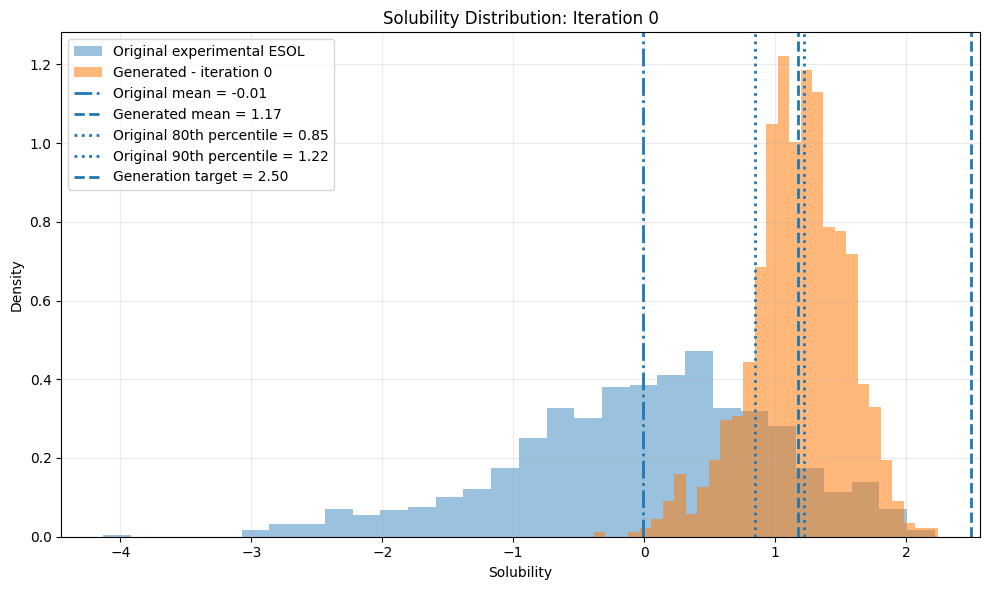


ITERATION 0: AUGMENT DATASET
New training dataset size: 2128
New solubility range: -4.133174419403076 to 2.247199773788452

ITERATION 1
Current training dataset size: 2128
Current solubility range: -4.133174419403076 to 2.247199773788452

THRESHOLD MATRIX THROUGH ITERATION 1
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110
         1 current_training_dataset 2128 -0.250955 0.854983 1.325962 1.546346

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.07971347868442535
  0.8470953464508059 1.2221097946166992]
 [1 'current_training_dataset' -0.2509548366069792 0.8549832999706268
  1.3259617567062378 1.5463458180427552]]

ITERATION 1: TRAIN VAE
Epoch 1/100
22/22 [==============================] - 1s 14ms/step - loss: 378.2660 - recon: 365.4442 - kl: 128.2176 - beta: 0.1000
Epoch 2/100
22/22 [==============================] - 0s 14ms/step - loss: 93.7984 -

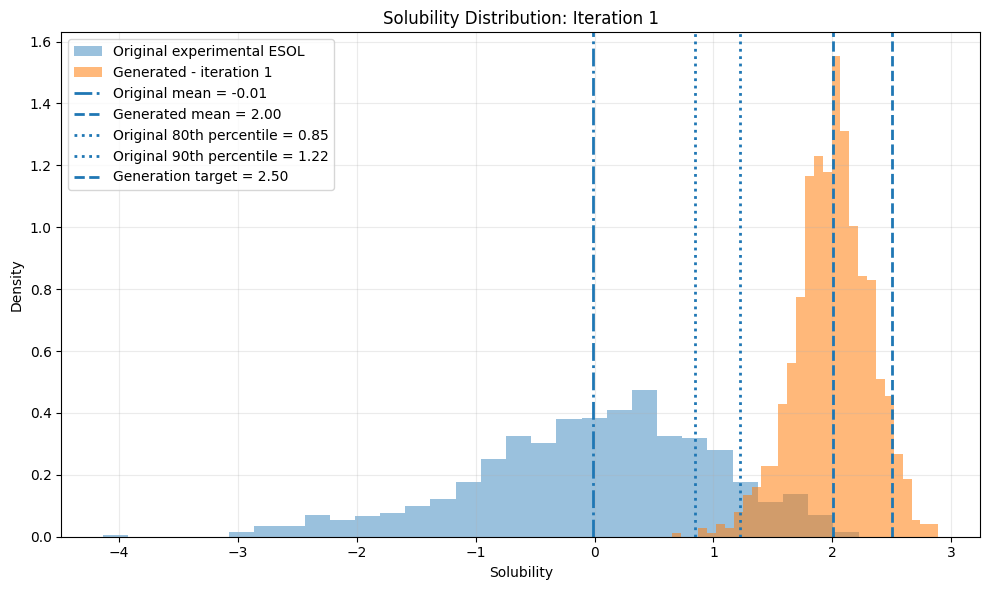


ITERATION 1: AUGMENT DATASET
New training dataset size: 3128
New solubility range: -4.133174419403076 to 2.8904154300689697

ITERATION 2
Current training dataset size: 3128
Current solubility range: -4.133174419403076 to 2.8904154300689697

THRESHOLD MATRIX THROUGH ITERATION 2
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110
         1 current_training_dataset 2128 -0.250955 0.854983 1.325962 1.546346
         2 current_training_dataset 3128  0.198484 1.222110 1.932905 2.145330

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.07971347868442535
  0.8470953464508059 1.2221097946166992]
 [1 'current_training_dataset' -0.2509548366069792 0.8549832999706268
  1.3259617567062378 1.5463458180427552]
 [2 'current_training_dataset' 0.198484140634537 1.2221097946166992
  1.9329054355621338 2.145329737663269]]

ITERATION 2: TRAIN VAE
Epoch 1/100
32/32 [=======

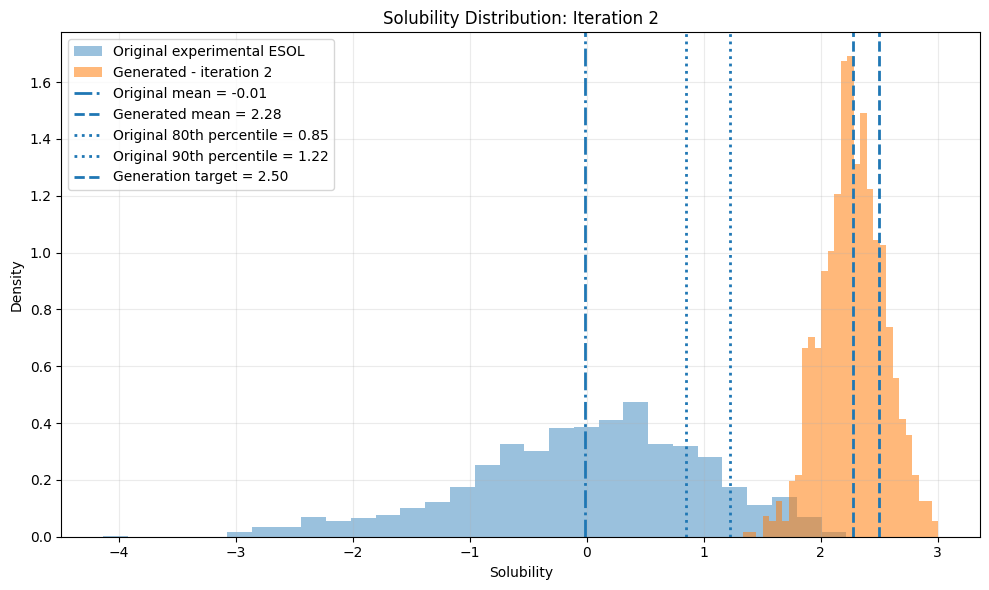


ITERATION 2: AUGMENT DATASET
New training dataset size: 4128
New solubility range: -4.133174419403076 to 3.005775213241577

ITERATION 3
Current training dataset size: 4128
Current solubility range: -4.133174419403076 to 3.005775213241577

THRESHOLD MATRIX THROUGH ITERATION 3
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110
         1 current_training_dataset 2128 -0.250955 0.854983 1.325962 1.546346
         2 current_training_dataset 3128  0.198484 1.222110 1.932905 2.145330
         3 current_training_dataset 4128  0.514964 1.601640 2.220430 2.403882

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.07971347868442535
  0.8470953464508059 1.2221097946166992]
 [1 'current_training_dataset' -0.2509548366069792 0.8549832999706268
  1.3259617567062378 1.5463458180427552]
 [2 'current_training_dataset' 0.198484140634537 1.2221097946166992
  1.93290543556

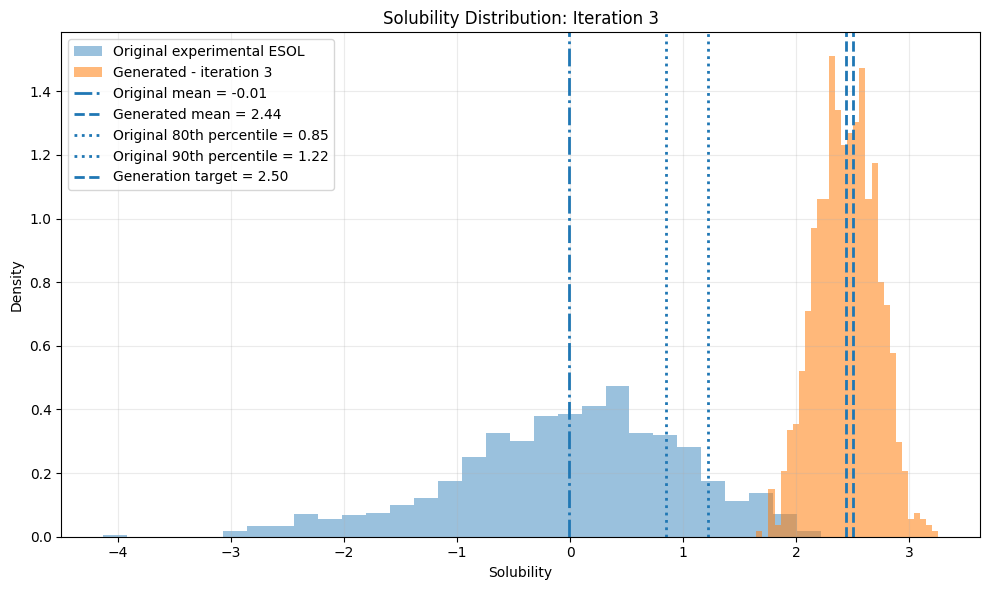


ITERATION 3: AUGMENT DATASET
New training dataset size: 5128
New solubility range: -4.133174419403076 to 3.2581446170806885

ITERATION 4
Current training dataset size: 5128
Current solubility range: -4.133174419403076 to 3.2581446170806885

THRESHOLD MATRIX THROUGH ITERATION 4
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110
         1 current_training_dataset 2128 -0.250955 0.854983 1.325962 1.546346
         2 current_training_dataset 3128  0.198484 1.222110 1.932905 2.145330
         3 current_training_dataset 4128  0.514964 1.601640 2.220430 2.403882
         4 current_training_dataset 5128  0.812390 1.903343 2.382654 2.565684

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.07971347868442535
  0.8470953464508059 1.2221097946166992]
 [1 'current_training_dataset' -0.2509548366069792 0.8549832999706268
  1.3259617567062378 1.5463458180427552]
 [2

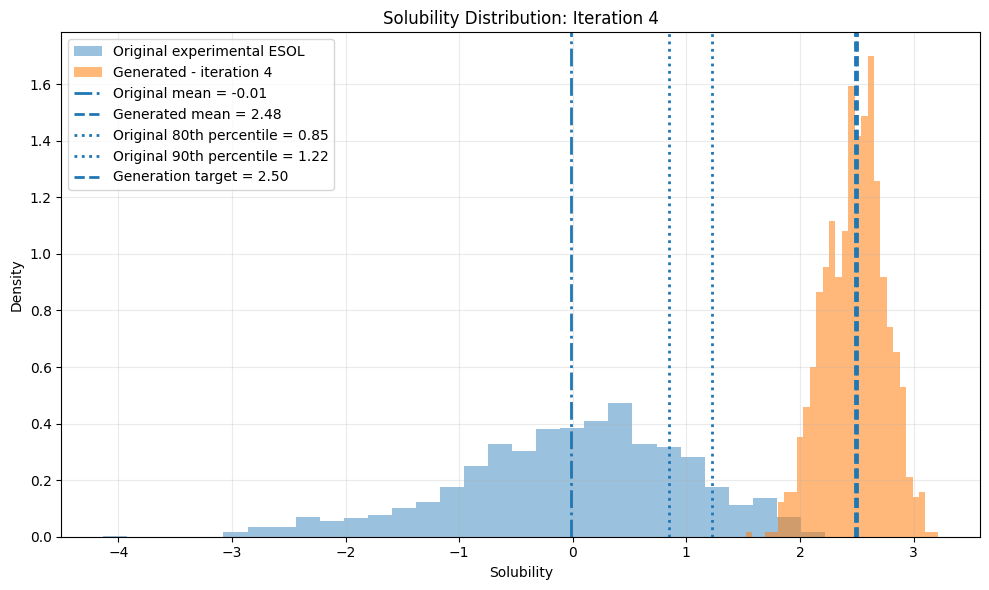


ITERATION 4: AUGMENT DATASET
New training dataset size: 6128
New solubility range: -4.133174419403076 to 3.2581446170806885

FINAL TRAINING-DATASET THRESHOLD MATRIX
 iteration                  dataset    N       p20      p50      p80      p90
         0 current_training_dataset 1128 -0.781181 0.079713 0.847095 1.222110
         1 current_training_dataset 2128 -0.250955 0.854983 1.325962 1.546346
         2 current_training_dataset 3128  0.198484 1.222110 1.932905 2.145330
         3 current_training_dataset 4128  0.514964 1.601640 2.220430 2.403882
         4 current_training_dataset 5128  0.812390 1.903343 2.382654 2.565684

Numeric threshold matrix:
[[0 'current_training_dataset' -0.7811809778213501 0.07971347868442535
  0.8470953464508059 1.2221097946166992]
 [1 'current_training_dataset' -0.2509548366069792 0.8549832999706268
  1.3259617567062378 1.5463458180427552]
 [2 'current_training_dataset' 0.198484140634537 1.2221097946166992
  1.9329054355621338 2.145329737663269]
 [3 'cur

In [68]:
# ============================================================

if __name__ == "__main__":
    main()